<a href="https://colab.research.google.com/github/ncminhbka/ML-Projects/blob/main/LSTM_Temperature_Forecasting.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Problem Statement: Given a dataset recorded temperature per hour (download here) Build a model that
given temperature from the previous 6 hours (including the current one), predict temperature of the next
1 hour.

=> Unlike Sentiment Analysis, this is a regression problem

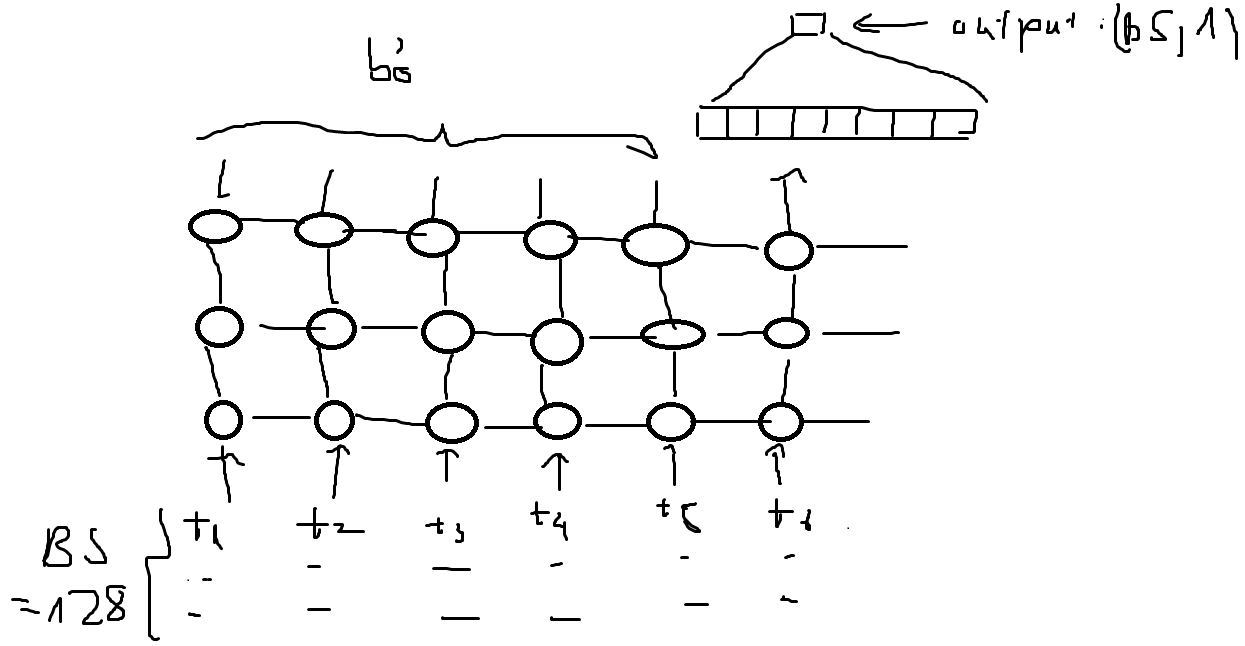

In [ ]:
!gdown --id 1F6kUoxIeDbc_oQO2ADtyIetzQkRdIc0r

/usr/local/lib/python3.12/dist-packages/gdown/__main__.py:140: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From: https://drive.google.com/uc?id=1F6kUoxIeDbc_oQO2ADtyIetzQkRdIc0r
To: /content/weather_forecast.zip
100% 2.34M/2.34M [00:00<00:00, 95.0MB/s]


In [ ]:
!unzip weather_forecast.zip

Archive:  weather_forecast.zip
  inflating: weatherHistory.csv      


In [ ]:
import torch
import torch.nn as nn

seed = 1
torch.manual_seed(seed)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from torch.utils.data import Dataset, DataLoader

In [ ]:
df = pd.read_csv('weatherHistory.csv')
df.head()
# fields in this dataset is vary, only choose temperature in this case

,Formatted Date,Summary,Precip Type,Temperature (C),Apparent Temperature (C),Humidity,Wind Speed (km/h),Wind Bearing (degrees),Visibility (km),Loud Cover,Pressure (millibars),Daily Summary
0,2006-04-01 00:00:00.000 +0200,Partly Cloudy,rain,9.472222,7.388889,0.89,14.1197,251.0,15.8263,0.0,1015.13,Partly cloudy throughout the day.
1,2006-04-01 01:00:00.000 +0200,Partly Cloudy,rain,9.355556,7.227778,0.86,14.2646,259.0,15.8263,0.0,1015.63,Partly cloudy throughout the day.
2,2006-04-01 02:00:00.000 +0200,Mostly Cloudy,rain,9.377778,9.377778,0.89,3.9284,204.0,14.9569,0.0,1015.94,Partly cloudy throughout the day.
3,2006-04-01 03:00:00.000 +0200,Partly Cloudy,rain,8.288889,5.944444,0.83,14.1036,269.0,15.8263,0.0,1016.41,Partly cloudy throughout the day.
4,2006-04-01 04:00:00.000 +0200,Mostly Cloudy,rain,8.755556,6.977778,0.83,11.0446,259.0,15.8263,0.0,1016.51,Partly cloudy throughout the day.


In [ ]:
temp_df = df['Temperature (C)']
type(temp_df) # temp_df is a pd series
temp_df.index = df['Formatted Date']
temp_df

,Temperature (C)
Formatted Date,
2006-04-01 00:00:00.000 +0200,9.472222
2006-04-01 01:00:00.000 +0200,9.355556
2006-04-01 02:00:00.000 +0200,9.377778
2006-04-01 03:00:00.000 +0200,8.288889
2006-04-01 04:00:00.000 +0200,8.755556
...,...
2016-09-09 19:00:00.000 +0200,26.016667
2016-09-09 20:00:00.000 +0200,24.583333
2016-09-09 21:00:00.000 +0200,22.038889


In [ ]:
temp_df[len(temp_df)-1]

/tmp/ipython-input-4272947430.py:1: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  temp_df[len(temp_df)-1]


np.float64(20.438888888888894)

In [ ]:
input_size = 6
label_size = 1
def slicing_window(series, input_size, label_size):
    features = []
    labels = []
    st_index = 0
    end_idx = len(series) - input_size - 1
    while st_index != end_idx:
        feature = series.iloc[st_index:st_index+input_size].values #.values to conver to np arr
        label = series.iloc[st_index+input_size]
        features.append(feature)
        labels.append(label)
        st_index += 1
    return np.array(features), np.array(labels)


In [ ]:
features, labels = slicing_window(temp_df, input_size, label_size)

In [ ]:
len(labels)

96446

In [ ]:
features.shape
features = features.reshape(features.shape[0], features.shape[1], 1) #or features = np.expand_dims(features, -1)
features.shape # (BS, sqlen, input dim)
features

array([[[ 9.47222222],
        [ 9.35555556],
        [ 9.37777778],
        [ 8.28888889],
        [ 8.75555556],
        [ 9.22222222]],

       [[ 9.35555556],
        [ 9.37777778],
        [ 8.28888889],
        [ 8.75555556],
        [ 9.22222222],
        [ 7.73333333]],

       [[ 9.37777778],
        [ 8.28888889],
        [ 8.75555556],
        [ 9.22222222],
        [ 7.73333333],
        [ 8.77222222]],

       ...,

       [[30.89444444],
        [31.08333333],
        [31.08333333],
        [30.76666667],
        [28.83888889],
        [26.01666667]],

       [[31.08333333],
        [31.08333333],
        [30.76666667],
        [28.83888889],
        [26.01666667],
        [24.58333333]],

       [[31.08333333],
        [30.76666667],
        [28.83888889],
        [26.01666667],
        [24.58333333],
        [22.03888889]]])

In [ ]:
train_size = 0.7 * len(temp_df)
val_size = 0.2 * len(temp_df)

X_train = features[:int(train_size)]
y_train = labels[:int(train_size)]
X_val = features[int(train_size):int(train_size)+int(val_size)]
y_val = labels[int(train_size):int(train_size)+int(val_size)]
X_test = features[int(train_size)+int(val_size):]
y_test = labels[int(train_size)+int(val_size):]


In [ ]:
X_test.shape

(9639, 6, 1)

In [ ]:
#experiment, original temperature vs scaled temperature
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

# MinMaxScaler() only works with 2D input (n_samples, n_features)
scaler.fit(X_train.reshape(-1, 1)) # only fit with train dataset
# Mô hình học máy luôn giả định rằng dữ liệu train và dữ liệu thực tế (val/test) đến từ cùng một phân phối

def transform(x):
    # x shape: (seq_len,)
    x_scaled = scaler.transform(x.reshape(-1, 1))
    return x_scaled


In [ ]:
class WeatherForecast(Dataset):
    def __init__(
        self,
        X, y,
        transform=None
    ):
        self.X = X
        self.y = y
        self.transform = transform

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        X = self.X[idx]
        y = self.y[idx]

        if self.transform:
            X = self.transform(X)

        X = torch.tensor(X, dtype=torch.float32)
        y = torch.tensor(y, dtype=torch.float32)

        return X, y

In [ ]:
#instance the class
train_dataset = WeatherForecast(X_train, y_train, transform)
val_dataset = WeatherForecast(X_val, y_val, transform)
test_dataset = WeatherForecast(X_test, y_test, transform)


In [ ]:
train_dataset.__getitem__(0)

(tensor([[0.5070],
         [0.5051],
         [0.5054],
         [0.4878],
         [0.4954],
         [0.5029]]),
 tensor(7.7333))

In [ ]:
#after we got dataset class, time to create dataloader
train_batch_size = 128
test_batch_size = 128
train_loader = DataLoader(train_dataset, batch_size=train_batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=test_batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=test_batch_size, shuffle=False)

In [ ]:
class WeatherForecastor(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, dropout_prob):
        super(WeatherForecastor, self).__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first = True)
        self.norm = nn.LayerNorm(hidden_size)
        self.dropout = nn.Dropout(dropout_prob)
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        x, (hn, cn) = self.lstm(x)
        x = x[:, -1, :] # last hidden state of the last layer
        x = self.norm(x)
        x = self.dropout(x)
        x = self.fc(x)
        return x

In [ ]:
input_size = 1
hidden_size = 8
num_layers = 3
dropout_prob = 0.2
device = 'cuda' if torch.cuda.is_available() else 'cpu'

model = WeatherForecastor(input_size, hidden_size, num_layers, dropout_prob).to(device)

In [ ]:
def evaluate(model, dataloader, criterion, device):
    model.eval()
    losses = 0
    with torch.no_grad():
        for X, y in dataloader:
            X = X.to(device)
            y = y.to(device)
            y_pred = model(X) #(BS, 1)
            loss = criterion(y_pred.squeeze(-1), y)
            losses += loss.item() #nho phai co .item()
        losses /= len(dataloader)
    return losses

In [ ]:
evaluate(model, val_loader, nn.MSELoss(), device)

tensor(225.8803, device='cuda:0')

In [ ]:
def fit(
    model,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    device,
    epochs
):
    train_losses = []
    val_losses = []
    for epoch in range(epochs):
        model.train()
        train_loss = 0
        for X, y in train_loader:
            X = X.to(device)
            y = y.to(device)
            y_pred = model(X)
            loss = criterion(y_pred.squeeze(-1), y)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            train_loss += loss
        train_loss /= len(train_loader)
        train_losses.append(train_loss.item()) #không có .item() cực kỳ dở, toàn tensor, ko vẽ dc, .item() trả về giá trị float Python ,tự động cắt rời khỏi GPU & gradient graph.
        val_loss = evaluate(model, val_loader, criterion, device)
        val_losses.append(val_loss)
        print(f'Epoch {epoch+1}/{epochs}, train loss: {train_loss:.4f}, val loss: {val_loss:.4f}')
    return train_losses, val_losses

In [ ]:
lr = 1e-3
epochs = 50

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=lr
)

In [ ]:
train_losses, val_losses = fit(
    model,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    device,
    epochs
)

Epoch 1/50, train loss: 155.6156, val loss: 69.9947
Epoch 2/50, train loss: 40.6970, val loss: 10.8775
Epoch 3/50, train loss: 17.7713, val loss: 4.8760
Epoch 4/50, train loss: 13.8596, val loss: 4.5568
Epoch 5/50, train loss: 11.7363, val loss: 2.2571
Epoch 6/50, train loss: 10.6349, val loss: 2.7112
Epoch 7/50, train loss: 10.3483, val loss: 1.8200
Epoch 8/50, train loss: 9.9498, val loss: 1.9337
Epoch 9/50, train loss: 9.5541, val loss: 1.7774
Epoch 10/50, train loss: 9.2953, val loss: 1.7719
Epoch 11/50, train loss: 9.1535, val loss: 1.8094
Epoch 12/50, train loss: 8.9338, val loss: 1.8620
Epoch 13/50, train loss: 8.6415, val loss: 2.2319
Epoch 14/50, train loss: 8.5580, val loss: 1.6015
Epoch 15/50, train loss: 8.3229, val loss: 1.7974
Epoch 16/50, train loss: 8.1670, val loss: 2.9661
Epoch 17/50, train loss: 8.0510, val loss: 1.5685
Epoch 18/50, train loss: 7.8430, val loss: 1.7899
Epoch 19/50, train loss: 7.7382, val loss: 2.0199
Epoch 20/50, train loss: 7.7146, val loss: 2.7259

In [ ]:
#train_losses = [x.detach().cpu().item() for x in train_losses]
val_losses = [x.detach().cpu().item() for x in val_losses]

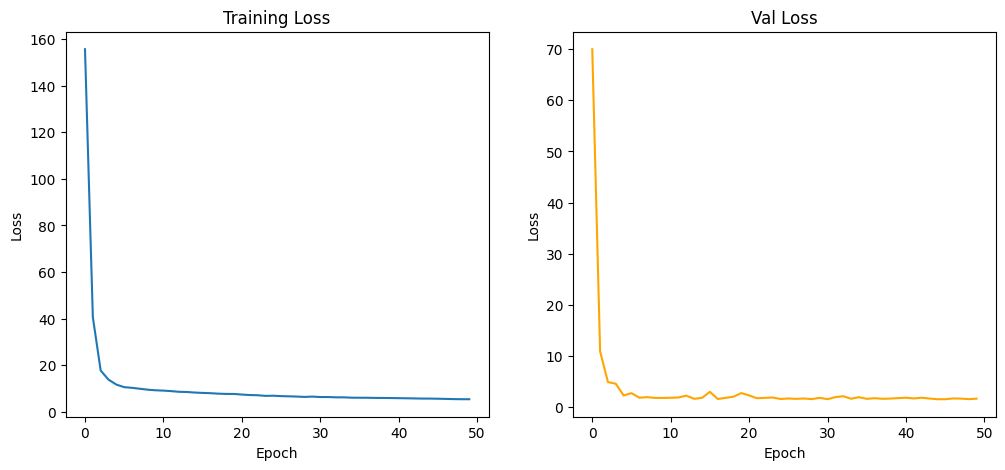

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
ax[0].plot(train_losses)
ax[0].set_title('Training Loss')
ax[0].set_xlabel('Epoch')
ax[0].set_ylabel('Loss')
ax[1].plot(val_losses, color='orange')
ax[1].set_title('Val Loss')
ax[1].set_xlabel('Epoch')
ax[1].set_ylabel('Loss')
plt.show()


In [ ]:
val_loss = evaluate(
    model,
    val_loader,
    criterion,
    device
)
test_loss = evaluate(
    model,
    test_loader,
    criterion,
    device
)

print('Evaluation on val/test dataset')
print('Val loss: ', val_loss)
print('Test loss: ', test_loss)

Evaluation on val/test dataset
Val loss:  tensor(1.6343, device='cuda:0')
Test loss:  tensor(1.4869, device='cuda:0')


In [ ]:
def plot_difference(y, y_pred):
    y_pred = y_pred.squeeze(-1).cpu().detach().numpy()
    plt.figure(figsize=(20, 6))
    times = range(len(y))
    plt.plot(times, y, color='steelblue', marker='o', label='True value')
    plt.plot(times, y_pred, color='orangered', marker='X', label='Prediction')
    plt.title('Temperature in every hours')
    plt.xlabel('Hour')
    plt.ylabel('Temperature (C)')
    plt.legend()
    plt.show()

In [ ]:
y = y_test[100:200]
X_infer = np.array([transform(i) for i in X_test[100:200]])
X_infer.shape
X_infer = torch.tensor(X_infer, dtype=torch.float32).to(device)
#X_infer = torch.from_numpy(X_infer) #cach 2 nhung cach nay dua ve float64
X_infer.shape
y_pred = model(X_infer.to(device))


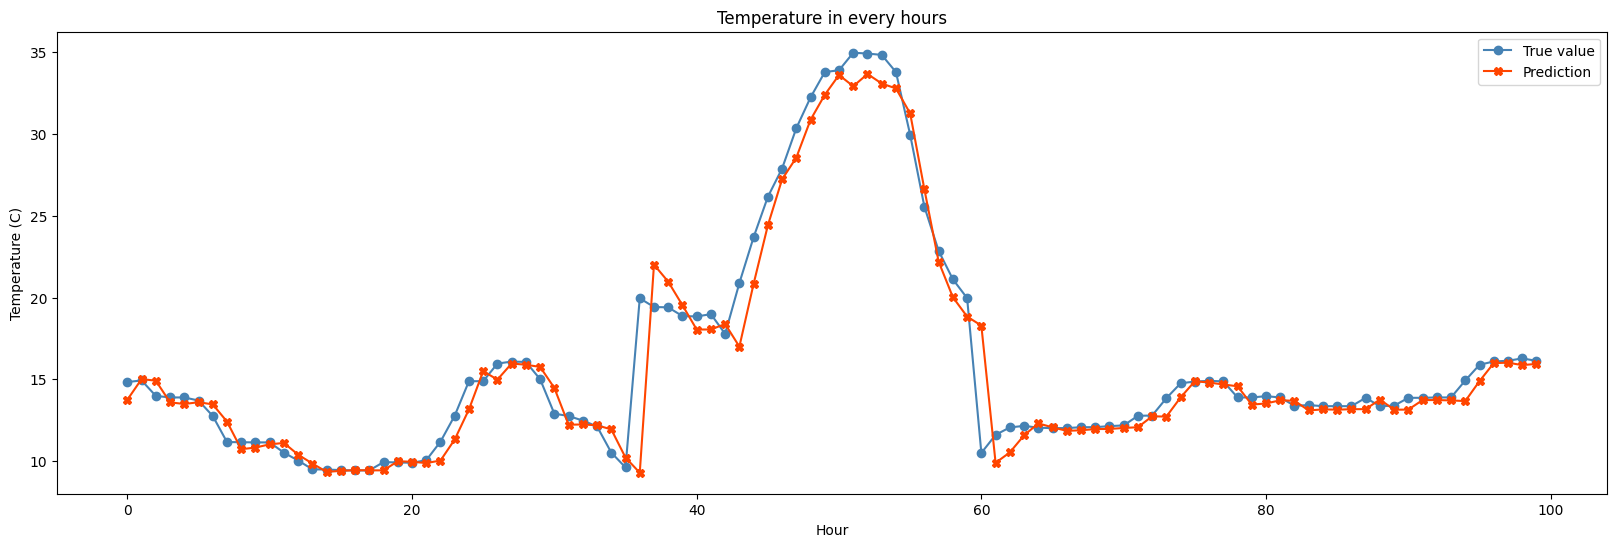

In [ ]:
plot_difference(y, y_pred)